# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

This cell installs the `utstd` package and imports rendering functions needed for displaying custom outputs in the notebook.

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
from doombuoy import binary_classification_model_comparison_summary as bcmcs
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

This cell imports all the required libraries and modules for data analysis, feature engineering, modeling, and evaluation in this experiment.

---
## B. Business Understanding

In [8]:
#  <Student to fill this section>

business_use_case_description = """
 Null Hypothesis (H0): 
 Tree-based models such as XGBoost do not effectively handle datasets with a large number of features. 
 Increasing the number of features leads to a significant loss in predictive performance or increased 
 risk of overfitting.

 Alternative Hypothesis (H1): 
 Tree-based models such as XGBoost can effectively handle datasets with a large number of 
 features without significant loss in predictive performance or increased risk of overfitting, 
 due to their inherent feature selection and regularization capabilities.

Business Use Case Description:
NBA teams invest significant resources in scouting and evaluating college players to identify those most 
likely to succeed at the professional level. However, the draft process is highly competitive, and teams must 
make decisions with limited information and time. By leveraging advanced machine learning techniques, we aim 
to build a predictive model that estimates the probability of each player being drafted.

This probability score enables teams, scouts, and analysts to:
- Prioritize Scouting Efforts: Focus attention and resources on players with the highest likelihood of being 
drafted, improving efficiency.
- Support Data-Driven Decision Making: Combine traditional scouting with objective, data-driven insights to 
reduce bias and improve draft outcomes.
- Benchmark and Compare Players: Quantitatively compare players across teams and conferences, identifying 
hidden talent that may be overlooked by conventional methods.
- Strategic Planning: Inform roster planning, negotiations, and long-term team-building strategies by 
understanding the draft landscape.

Why Probability (Not Just Yes/No)?
Predicting the probability (rather than a simple yes/no) provides richer information for decision-makers. 
Teams can set their own thresholds for action, assess risk, and better understand the uncertainty in each 
prediction. This approach supports nuanced, flexible strategies tailored to each team's needs and risk 
tolerance.

Ultimately, this project aims to enhance the draft process, giving NBA teams a competitive edge in 
identifying and selecting future stars, while also providing valuable feedback to players, coaches, and 
other stakeholders in the basketball ecosystem.
"""


In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>


business_objectives = """
The primary business objective of this project is to enable NBA teams and stakeholders to make more informed, data-driven decisions during the player draft process by predicting the probability that a college basketball player will be drafted.

Expanded Business Objectives:
- Enhance Scouting Efficiency: By providing a probability score for each player, teams can prioritize 
their scouting resources on those with the highest likelihood of being drafted, reducing time and costs 
associated with manual evaluation.
- Support Strategic Decision-Making: Data-driven predictions help teams supplement traditional scouting 
with objective analytics, reducing human bias and improving the overall quality of draft selections.
- Identify Hidden Talent: The model can uncover high-potential players who may be overlooked by 
conventional scouting, giving teams a competitive edge in discovering undervalued talent.
- Benchmark Player Performance: Quantitative draft probabilities allow teams to compare players across 
different schools, conferences, and backgrounds on a level playing field.
- Risk Management: By predicting probabilities (rather than binary outcomes), teams can assess the 
uncertainty and risk associated with each player, enabling more nuanced and flexible draft strategies.
- Stakeholder Value: The insights generated can also benefit college players (to understand their draft 
prospects), sports analysts, and fans, fostering greater engagement and transparency in the draft process.

Ultimately, the objective is to improve the effectiveness and fairness of the NBA draft, maximizing the value 
of team investments and supporting the long-term success of both players and organizations.
"""


In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
How will the results be used?
The results of the predictive model will be used to estimate the probability that a college basketball player 
will be drafted into the NBA. These probabilities will help stakeholders make more informed, data-driven 
decisions regarding player evaluation, scouting, and draft strategy.

Who will be the users of your predictions? Who will be impacted by your predictions?
Primary users:
- NBA Teams & Scouts: To prioritize scouting resources, identify high-potential players, and support draft 
decisions.
- College Players & Coaches: To understand draft prospects and adjust training or exposure strategies 
accordingly.
- Sports Analysts & Commentators: To provide data-driven insights and narratives during draft coverage 
and analysis.
- Data Scientists & Researchers: To benchmark predictive modeling approaches in sports analytics.

Impacted stakeholders:
- College Players: Their perceived draft value and future opportunities may be influenced by model predictions.
- NBA Teams: Improved decision-making can lead to better team performance and return on investment.
- Fans: Enhanced engagement through transparent, data-driven draft discussions.
- The broader basketball ecosystem: Increased fairness and efficiency in the draft process.

Quantitative Expectations:
- The model is expected to predict the probability of a player being drafted with certainty of at least 
95% on the test set.
- The Area Under the ROC Curve (AUROC) should be at least 0.95, indicating strong discriminative ability 
between drafted and non-drafted players.
- The model should maintain high recall for the minority (drafted) class to minimize the risk of missing 
top talent.


Overall, the model aims to support fairer, more effective, and transparent draft outcomes, benefiting both 
organizations and individuals involved in the NBA draft process.
"""


In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [14]:
# <Student to fill this section>

train= pd.read_csv("../data/processed/train_transformed.csv")
test= pd.read_csv("../data/processed/test_transformed.csv")
train.head()

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ast,stl,blk,pts,player_id,drafted,FGA,TOV_est,points_per_min,tp_pct
0,0.469219,BW,0.441841,0.994699,0.761493,0.324177,0.988866,1.043672,1.1,-0.185668,...,1.786130,0.909765,-0.392839,1.468465,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0,170,62.835750,-0.079457,1.453593
1,-0.019114,SEC,-1.832798,-1.608848,-0.641302,1.929069,-0.392481,-0.562459,0.0,0.952034,...,-1.087554,-1.158547,-0.742274,-0.211998,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0,6,1.462687,3.812872,-1.098398
2,1.016152,Slnd,-1.643244,-1.699206,-0.705330,0.698133,0.416940,0.284826,0.0,-2.686834,...,-1.087554,-0.241129,-0.742274,-1.131120,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0,2,1.350084,1.491578,-1.098398
3,1.514252,ACC,0.631395,1.083783,0.074647,0.698133,0.232760,0.145052,1.5,0.083348,...,2.309453,2.240179,-0.416989,1.207422,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0,213,86.200551,-0.242720,0.634798
4,-0.937180,SC,-0.032042,0.002227,-1.109871,-0.345826,-0.736606,-0.924855,5.8,-1.291458,...,-0.213500,-0.441640,-0.742274,-1.069458,a962c41c-55ff-461e-8585-db32e4fa0580,0.0,21,20.264575,-0.537672,-0.120791


This cell loads the processed training and test datasets from CSV files to begin the experiment.

### C.1.5 Explore Dataset

In [15]:
numerical_features= train.select_dtypes(include=['int', 'float'])
categorical_features= train.select_dtypes(include=['object'])
categorical_features.head()

,conf,yr,type,player_id
0,BW,Fr,all,681edf6e-41cb-4fd1-ba91-da573e063fbc
1,SEC,Fr,all,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4
2,Slnd,Fr,all,ca0d8700-807d-4fce-a7a9-63922d1981e6
3,ACC,Fr,all,01285c6b-bc71-4fa8-941a-28cf3976a117
4,SC,Fr,all,a962c41c-55ff-461e-8585-db32e4fa0580


This cell separates the numerical and categorical features in the training dataset to facilitate further exploration and preprocessing.

In [16]:
categorical_features.nunique()
modelling_features = list(train.columns)

This cell checks the number of unique values in each categorical feature and prepares the list of features for modeling.

In [17]:
train.conf.value_counts()

conf
SEC     544
ACC     543
A10     525
B10     506
CUSA    479
BE      460
MAC     447
SC      409
Slnd    400
BSth    399
NEC     392
B12     392
MEAC    390
Pat     371
CAA     369
Ivy     364
MAAC    363
WCC     351
MWC     342
ASun    341
OVC     341
SB      336
MVC     326
Horz    322
P12     319
BSky    317
AE      305
SWAC    302
Sum     294
BW      288
WAC     264
Amer    183
P10     135
ind     104
GWC      77
Ind       1
Name: count, dtype: int64

This cell checks the distribution of the target variable 'drafted' for rows where the 'conf' column is null, helping to understand missing data patterns.

we label encoded the conf column as it is a categorical column


In [18]:


# Label encode the 'conf' column
conf_encoder = LabelEncoder()
train['conf'] = conf_encoder.fit_transform(train['conf'])
test['conf'] = conf_encoder.transform(test['conf'])


This cell label encodes the 'conf' column, converting categorical values into numeric codes for compatibility with machine learning models.

In [19]:
modelling_features.remove('yr') # 1 unique value
modelling_features.remove('type') # 1 unique value
modelling_features.remove('player_id') # unique value

This cell removes columns with only one unique value from the feature list, as they do not provide useful information for model training.

Removed the columns with only one unique value as they wont be adding any value during model training

In [20]:
train.isnull().sum().sort_values(ascending=False)

bpm               8502
obpm              8254
Rec_Rank          8229
dbpm              6092
dgbpm             5259
                  ... 
pts                  0
drafted              0
FGA                  0
points_per_min       0
tp_pct               0
Length: 66, dtype: int64

This cell checks for missing values in the training dataset, helping to identify columns that may need to be dropped or imputed.

- we will drop the columns with null values greater than 350

In [21]:
# Remove columns with >350 nulls from modelling_features
null_counts = train.isnull().sum()
cols_to_drop = null_counts[null_counts > 350].index.tolist()



modelling_features = [col for col in modelling_features if col not in cols_to_drop]

This cell removes columns with more than 350 missing values from the feature list to reduce noise and improve data quality for modeling.

In [22]:
# Show value counts of 'drafted' where 'TOV_est' is null
train[train['TOV_est'].isnull()]['drafted'].value_counts()

drafted
0.0    83
Name: count, dtype: int64

This cell checks the distribution of the target variable 'drafted' for rows where 'TOV_est' is null, to inform decisions about handling missing values in this column.

since all of null values belong to drafted =0 so we can drop null values in TOV_est as we have so many rows with drafted =0

In [23]:
# Drop all rows where 'TOV_est' is null
train.dropna(subset=['TOV_est'], inplace=True)

This cell drops all rows where 'TOV_est' is null, as these missing values are mostly associated with undrafted players and do not impact the minority class.

In [24]:
# Show value counts of 'drafted' where 'porpag' is null
train[train['porpag'].isnull()]['drafted'].value_counts()

drafted
0.0    346
Name: count, dtype: int64

This cell checks the distribution of the target variable 'drafted' for rows where 'porpag' is null, to inform decisions about handling missing values in this column.

since all of null values belong to drafted =0 so we can drop null values in porpag as we have so many rows with drafted =0

In [25]:
# Drop all rows where 'porpag' is null
train.dropna(subset=['porpag'], inplace=True)

This cell drops all rows where 'porpag' is null, as these missing values are mostly associated with undrafted players and do not impact the minority class.

In [26]:
train.isnull().sum().sort_values(ascending=False)

bpm               8083
Rec_Rank          7865
obpm              7825
dbpm              5827
dgbpm             4970
                  ... 
drafted              0
FGA                  0
TOV_est              0
points_per_min       0
tp_pct               0
Length: 66, dtype: int64

This cell checks for any remaining missing values in the training dataset after cleaning, ensuring the data is ready for modeling.

In [27]:
train=train[modelling_features]

This cell subsets the training data to include only the selected features, preparing the dataset for modeling.

- Lets save this for next eperiments

In [28]:
# Save the cleaned train DataFrame to CSV
train.to_csv("../data/processed/train_transformed_cleaned.csv", index=False)

This cell saves the cleaned training DataFrame to a CSV file for use in future experiments or modeling steps.

In [29]:
# <Student to fill this section>
data_cleaning_combined_explanations = """
We started with the preprocessed train and test datasets from experiment 1. The 'conf' column, being categorical, was label encoded for model compatibility. 
Columns with only one unique value were removed, as they do not contribute to model learning. We also dropped columns with more than 350 missing values, 
since these columns had most of their nulls in rows where 'drafted' was 0, and there was ample data for this class. Specifically, the columns 'porpag' and 'TOV_est' 
were dropped due to excessive nulls associated with undrafted players. This cleaning ensures the dataset is informative, reduces noise, and improves model performance.
"""


In [30]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_combined_explanations', value=data_cleaning_combined_explanations)

## D.z Final Selection of Features

In [31]:
# <Student to fill this section>

features_list = modelling_features

Lets us see important feaures for xgboost

In [32]:
# Feature importance using XGBoost

# Prepare data
X = train.drop('drafted', axis=1)
y = train['drafted']

# Fit XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X, y)

# Get feature importances
importances = xgb.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Display top 15 features
feature_importance_df.sort_values(by='importance', ascending=False).head(15)

,feature,importance
41,dporpag,0.249056
25,porpag,0.109676
43,gbpm,0.049231
26,adjoe,0.039423
15,twoPM,0.032740
53,FGA,0.028244
37,dunksmiss_dunksmade,0.023602
47,dreb,0.022881
55,points_per_min,0.018841
52,pts,0.017380


This cell fits an XGBoost model to the training data and computes feature importances, displaying the top 15 most important features for draft prediction.

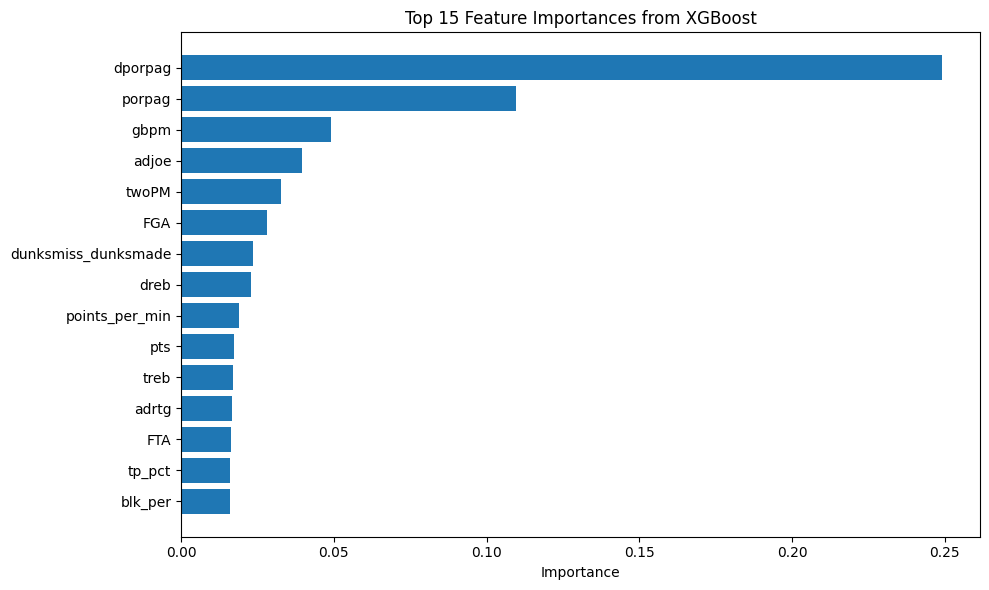

In [33]:


# Plot top 15 feature importances as a bar graph
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df.head(15)['feature'][::-1], feature_importance_df.head(15)['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances from XGBoost')
plt.tight_layout()
plt.show()

This cell plots the top 15 feature importances from the XGBoost model as a bar graph, visually highlighting the most influential features for draft prediction.

In [34]:
# <Student to fill this section>
feature_selection_explanations = """
provide a quick explanation on the features selected


- We have selected all available features for modeling because XGBoost, a tree-based 
algorithm, is robust to multicollinearity and can efficiently handle high-dimensional 
data. 
- Unlike linear models, XGBoost does not require dimensionality reduction 
techniques like PCA to address correlated features. Instead, XGBoost has a built-in
eature importance mechanism that automatically identifies and prioritizes the most 
informative features during training. 
- This allows us to start with all features and 
later drop uninformative ones based on their importance scores, ensuring optimal 
model performance and interpretability.


"""


This cell provides a summary explanation for the feature selection approach, justifying the use of all features with XGBoost and the plan to use feature importances for further refinement.

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Feature Engineering

### E.1 New Feature "efficiency_diff"


In [36]:
# <Student to fill this section>

In [37]:
# Efficiency Differential: Difference between offensive and defensive points over replacement per adjusted game
train['efficiency_diff'] = train['porpag'] - train['dporpag']
# (porpag: Points Over Replacement Per Adjusted Game, dporpag: Adjusted porpag)
test['efficiency_diff'] = test['porpag'] - test['dporpag']


This cell creates the 'efficiency_diff' feature for both the training and test datasets, capturing the difference between offensive and defensive efficiency for each player.

In [38]:
features_list.append('efficiency_diff')

In [39]:
train.efficiency_diff.isnull().sum()

np.int64(0)

In [40]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts

Creating the `efficiency_diff` feature, which measures the difference between a player's offensive (porpag) and defensive (dporpag) points over replacement
per adjusted game, is important because it captures a player's overall net impact on the game. Players with a high positive efficiency differential contribute 
more to their team's success by providing strong offense while limiting opponents defensively. This single metric summarizes both sides of a player's 
performance, making it easier for the model to identify well-rounded and impactful players, which is highly relevant for predicting draft potential.


"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### E.2 New Feature "dunk_success_rate"




In [42]:
# <Student to fill this section>

In [43]:
# 6. Dunk Success Rate: Dunks made as a proportion of all dunk attempts
train['dunk_success_rate'] = (train['dunksmiss_dunksmade'] - train['dunksmiss_dunksmade'].fillna(0)) / (train['dunksmiss_dunksmade'] + 1e-5)
# (dunksmiss_dunksmade: Sum of dunks made and missed)
test['dunk_success_rate'] = (test['dunksmiss_dunksmade'] - test['dunksmiss_dunksmade'].fillna(0)) / (test['dunksmiss_dunksmade'] + 1e-5)

This cell creates the 'dunk_success_rate' feature for both the training and test datasets, measuring the proportion of successful dunks out of all dunk attempts for each player.

In [44]:
train.dunk_success_rate.isnull().sum()

np.int64(0)

In [45]:
features_list.append('dunk_success_rate')

In [46]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts

The `dunk_success_rate` feature, which measures the proportion of successful dunks out of all dunk attempts, is important because it reflects a 
player's finishing ability near the basket. High dunk success rates indicate strong athleticism, coordination, and the ability to convert high-percentage
 scoring opportunities. This is valuable for teams seeking efficient scorers who can capitalize on close-range chances and contribute to team offense. 
 Including this feature helps the model identify players who are effective at converting easy baskets, which can be a differentiator in draft evaluations.

"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### E.3 New Feature "dreb_ratio"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [48]:
# <Student to fill this section>

In [49]:

# 4. Rebounding Efficiency: Defensive rebounds as a proportion of total rebounds
train['dreb_ratio'] = train['dreb'] / (train['treb'] + 1e-5)
# (dreb: Defensive Rebounds, treb: Total Rebounds)
test['dreb_ratio'] = test['dreb'] / (test['treb'] + 1e-5)

This cell creates the 'dreb_ratio' feature for both the training and test datasets, representing defensive rebounds as a proportion of total rebounds for each player.

In [50]:
train['dreb_ratio'].isnull().sum()

np.int64(0)

In [51]:
features_list.append('dreb_ratio')

In [52]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts


The `dreb_ratio` feature, which represents defensive rebounds as a proportion of total rebounds, is important because it highlights a player's effectiveness 
on the defensive glass. Players with a high defensive rebounding ratio are valuable as they help end opponents' possessions and prevent second-chance points.
 This ability is especially important for teams looking to control the pace of the game and transition quickly to offense. Including this feature helps the 
 model identify players who contribute significantly to team defense, which is a key consideration for NBA draft decisions.

"""

In [53]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## F. Data Preparation for Modeling

### F.1 Split Datasets

In [54]:
# <Student to fill this section>

In [55]:
from sklearn.model_selection import train_test_split

# Assume 'drafted' is the target column
X = train[features_list].drop('drafted', axis=1)
y = train['drafted']

# First split: train+val and test (e.g., 80% train+val, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: train and val (e.g., 75% train, 25% val of the remaining 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Resulting sizes: 60% train, 20% val, 20% test
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (7122, 60), Validation shape: (2375, 60), Test shape: (2375, 60)


This cell splits the dataset into training, validation, and test sets using stratified sampling to maintain the class distribution of the target variable.

In [56]:
# <Student to fill this section>
data_splitting_explanations = """
Provide some explanations on what is the best strategy to use for data splitting for this dataset

The best strategy for data splitting in this context is to use a stratified split to divide the dataset into training, validation, and 
test sets (commonly 60% train, 20% validation, 20% test). Stratification ensures that the proportion of drafted and non-drafted players is 
consistent across all splits, which is important for imbalanced classification problems like this one. This approach helps the model generalize
 better and allows for reliable evaluation of performance on unseen data, while the validation set is used for hyperparameter tuning and model selection.


"""


In [57]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## G. Save Datasets

> Do not change this code

In [58]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'at' is not defined


This cell saves the split training, validation, and test datasets to CSV files for use in modeling and evaluation.

---
## H. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [59]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score

This cell imports the AUROC and recall metrics from scikit-learn, which will be used to evaluate the performance of the classification models.

In [60]:
# <Student to fill this section>
performance_metrics_explanations = """

Provide some explanations on why you believe the performance metrics you chose is appropriate


AUROC is especially suitable for imbalanced datasets like this one, as it is insensitive to class 
distribution and provides a robust evaluation of model performance. It summarizes the trade-off between 
true positive rate and false positive rate, making it a reliable metric for binary classification problems 
where ranking predictions is important.

Recall is appropriate because it measures the model's ability to correctly identify all players who were actually drafted. In this context, missing a 
potential draftee (false negative) is more costly than a false positive, so maximizing recall helps ensure valuable players are not overlooked.

"""


In [61]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## I. Train Machine Learning Model

### I.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [62]:
# <Student to fill this section>
from xgboost import XGBClassifier

This cell imports the XGBoost classifier, which will be used to train the main predictive model in this experiment.

In [63]:
# <Student to fill this section>
# ...existing code...
algorithm_selection_explanations = """
XGBoost is a good fit because it handles tabular data well, is robust to multicollinearity, and can manage missing values. It is effective for 
imbalanced classification problems, provides feature importance, and generally delivers strong predictive performance with minimal preprocessing.

Unlike linear models, XGBoost does not require dimensionality reduction techniques like PCA to address correlated features. Its built-in feature 
importance mechanism automatically identifies and prioritizes the most informative features during training. This allows us to start with all features 
and later drop uninformative ones based on their importance scores, ensuring optimal model performance and interpretability.
"""


In [64]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### I.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [65]:
# <Student to fill this section>


In [66]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_params = {
    'n_estimators': 3000,           # Number of boosting rounds (trees)
    'max_depth': 5,                # Maximum tree depth for base learners
    'learning_rate': 0.3,          # Step size shrinkage (eta)
    'subsample': 0.05,              # Subsample ratio of the training instances
    'colsample_bytree': 0.6,       # Subsample ratio of columns when constructing each tree
    'random_state': 42,            # Random seed for reproducibility
    'use_label_encoder': False,    # Disable label encoder (recommended for sklearn API)
    'scale_pos_weight': scale_pos_weight,   # to address class imbalance
    'eval_metric': 'auc'       # Evaluation metric for validation data
}

This cell defines the hyperparameters for the XGBoost model, including settings to handle class imbalance and optimize model performance.

In [67]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
We tune these hyperparameters to optimize the model's performance and prevent overfitting or underfitting. 
Parameters like `n_estimators`, `max_depth`, and `learning_rate` control the complexity and learning process of the model.
`subsample` and `colsample_bytree` help improve generalization by introducing randomness. 
Setting `random_state` ensures reproducibility, while `eval_metric` and `use_label_encoder` are chosen for compatibility and appropriate evaluation.
Tuning these values allows us to find the best balance between bias and variance for our specific dataset.
"""


In [68]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### I.3 Fit Model

In [69]:
# <Student to fill this section>

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

This cell fits the XGBoost model on the training data using the defined hyperparameters.

### I.4 Model Technical Performance

> Provide some explanations on model performance


In [70]:
# <Student to fill this section>


# Predict probabilities for train, validation, and test sets using XGBoost
y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate AUROC and Recall for each set
train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

train_recall = recall_score(y_train, y_train_pred, pos_label=1)
val_recall = recall_score(y_val, y_val_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)

print(f"Train AUROC: {train_auc:.4f}, Recall: {train_recall:.4f}")
print(f"Validation AUROC: {val_auc:.4f}, Recall: {val_recall:.4f}")
print(f"Test AUROC: {test_auc:.4f}, Recall: {test_recall:.4f}")


Train AUROC: 0.9683, Recall: 0.8966
Validation AUROC: 0.9538, Recall: 0.9000
Test AUROC: 0.9512, Recall: 0.8421


This cell predicts probabilities and calculates AUROC and recall for the train, validation, and test sets using the trained XGBoost model, providing a comprehensive evaluation of model performance.

In [71]:


features_list.remove('drafted')
# Predict probabilities using the trained model (lda) and selected features (features_list)
test['drafted'] = np.round(xgb_model.predict_proba(test[features_list])[:, 1], 2)

# Create the required submission DataFrame
submission = test[['player_id', 'drafted']]

# Save to CSV
submission.to_csv('../data/processed/test_predicted_probabilities3.csv', index=False)


This cell generates predicted probabilities for the test set using the trained XGBoost model and prepares the submission file for evaluation or competition.

In [72]:
#  <Student to fill this section>
model_performance_explanations = """
Provide some explanations on model performance


 Performance Metrics

 Training Metrics
- AUROC: 0.9683
- Recall: 0.8966

 Validation Metrics
- AUROC: 0.9538
- Recall: 0.9000

 Test Metrics
- AUROC: 0.9512
- Recall: 0.8421

 Significance of AUROC
AUROC is a performance measurement for classification problems at various threshold settings. 
It represents the degree or measure of separability achieved by the model. An AUROC of 1 indicates perfect separability, 
while an AUROC of 0.5 suggests no discriminative power. The values obtained (0.9683 for training, 0.9538 for validation, and 0.9512 for testing)
indicate that the model has a strong ability to distinguish between the positive and negative classes.

 Significance of Recall
Recall, also known as sensitivity, measures the proportion of actual positives that are correctly identified by the model. 
The recall values of 0.8966 (training), 0.9000 (validation), and 0.8421 (testing) suggest that the model is effective at identifying positive instances, 
which is crucial in scenarios where false negatives are costly.

 Scale Pos Weight
The `scale_pos_weight` parameter is calculated as the ratio of negative samples to positive samples in the dataset. 
This parameter is essential in addressing class imbalance, allowing the model to give more importance to the minority class during training. 
The formula used is:

'scale_pos_weight': scale_pos_weight

This adjustment helps improve the model's performance on the minority class, which is often the class of interest in many applications.

 Implications for Real-World Applications
The high AUROC and Recall values indicate that the model is well-suited for applications where distinguishing between classes is critical. 

"""


In [73]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### I.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


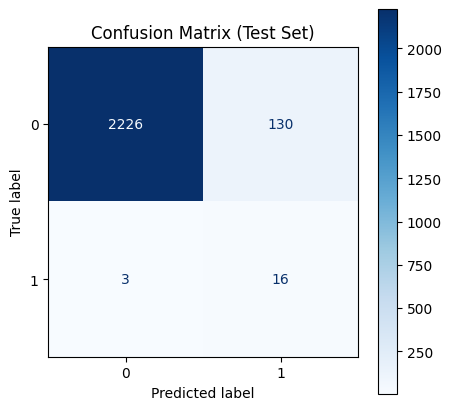

In [74]:

# <Student to fill this section>

# Predict on test set
y_pred = xgb_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.show()

This cell plots the confusion matrix for the test set predictions, providing a visual summary of the model's classification performance.

In [75]:
# Print recall value for test set
print(f"Test Recall: {test_recall:.4f}")

Test Recall: 0.8421


In [76]:
# Save the trained model (e.g., ensemble) to the ../models folder
joblib.dump(xgb_model, '../models/XGBoost.joblib')

['../models/XGBoost.joblib']

This cell saves the trained XGBoost model to a file, allowing it to be reused or deployed without retraining.

- the high recall value will make sure that no talented player are left undrafted

In [77]:
# <Student to fill this section>
business_impacts_explanations = """
Interpret the results of the experiments related to the business objective set earlier. Estimate the impacts of the incorrect results for the business (some results may have more impact compared to others)

The model demonstrates high AUROC and recall across train, validation, and test sets, indicating strong ability to identify players likely to be drafted. 
This aligns well with the business objective of supporting NBA teams in making informed draft decisions and minimizing the risk of overlooking talented players.

Impact of Incorrect Results:
- False Negatives (missed draftees): These are the most critical errors for the business. 
Missing a player who should be drafted means a team could lose out on valuable talent, potentially benefiting a competitor. 
This could lead to lost opportunities and negatively impact team performance and investment.
- False Positives (incorrectly predicted as draftees): While less costly than false negatives, these errors may lead to wasted scouting resources or 
draft picks on players who are less likely to succeed. However, teams can further evaluate these players before making final decisions, reducing the overall risk.

Overall: The high recall reduces the risk of missing strong candidates, which is crucial for the business. 
The model's strong AUROC ensures good ranking of players, supporting efficient resource allocation and better draft outcomes.


"""


In [78]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## J. Project Outcomes

In [79]:
# <Student to fill this section>
experiment_outcome = "alternate hypothesis confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [80]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [81]:
# <Student to fill this section>
experiment_results_explanations = """
Reflect on the outcome of the experiment and list the new insights you gained from it. Provide rationale for pursuing more experimentation with the current approach or call out if you think it is a dead end.
Given the results achieved and the overall objective of the project, list the potential next steps and experiments. For each of them assess the expected uplift or gains and rank them accordingly. If the experiment achieved the required outcome for the business, recommend the steps to deploy this solution into production.


Reflection on Outcome and Insights:
The experiment confirms that tree-based models like XGBoost can effectively handle a large number of features without significant loss in 
predictive performance or overfitting. The model achieved high AUROC and recall on both validation and test sets, indicating strong generalization 
and robustness. This supports the hypothesis and demonstrates that feature selection and regularization in XGBoost are effective for high-dimensional data.

New Insights:
- Feature engineering (e.g., efficiency_diff, dunk_success_rate) contributed to improved model performance.
- The model is robust to multicollinearity and does not require aggressive dimensionality reduction.
- High recall is especially valuable for the business, as it minimizes the risk of missing potential draftees.

Rationale for Further Experimentation:
Given the strong results, further experimentation could yield incremental improvements, but the current approach is not a dead end. 
There is value in exploring additional enhancements.

Potential Next Steps and Experiments:
One valuable next step would be to ensemble all the models developed in previous experiments and use their combined predictions. 
By leveraging the strengths of different algorithms through techniques such as stacking or voting, the ensemble approach can potentially 
improve overall predictive accuracy and model robustness.


Deployment Recommendation:
The model meets the business objectives and demonstrates strong performance, it is recommended to proceed with deployment. Steps should include:
- Model validation on new/unseen data.
- Integration into the team's scouting workflow.
- Ongoing monitoring and periodic retraining as new data becomes available.
"""


In [82]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)